# TA Full-Pool SHAP Importance Ranking

**Goal**: Understand which TA/Qlib features are genuinely informative for the 5-day
excess-return target — using fold-local SHAP (leakage-free) across all 7 walk-forward
folds. This is a **diagnostic**, not a performance experiment.

**Pool**: 30 locked base features + 25 TA candidates (all `td_*` columns not already
in the model, excluding forward-looking columns `td_fwd5` / `td_return_5d_fwd`).

For each fold:
1. Train on all 55 features (training window only)
2. Compute SHAP on **training data only** — no leakage from test
3. Record mean |SHAP| per feature

Output: global SHAP rank table + fold selection frequency at top-10 / top-20 / top-30.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

NOTEBOOK_DIR  = Path('').resolve()
ROOT          = NOTEBOOK_DIR.parents[2]
FINAL_ART_DIR = ROOT / 'step3_predictive_model/final_model/artifacts'

for p in [str(ROOT),
          str(ROOT / 'step3_predictive_model/model_experiments')]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'ROOT : {ROOT}')

ROOT : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis


## 1. Load Config & Dataset

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

locked_pkls = sorted(FINAL_ART_DIR.glob('lgbm_3class_xfn5d_30f_tuned-*.pkl'))
assert locked_pkls
with open(locked_pkls[-1], 'rb') as f:
    locked = pickle.load(f)

BASE_FEATURES = locked['features']
TARGET        = locked['target']
THRESHOLD     = locked['threshold']
label_map     = locked['label_map']
inv_map       = locked['inverse_label_map']
LOCKED_PARAMS = locked['best_params']

df = load_dataset()
print(f'Dataset: {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Base features: {len(BASE_FEATURES)}')

Dataset: 1285 rows  |  2021-02-25 → 2026-04-09
Base features: 30


## 2. Build the 55-Feature Pool

In [3]:
# All td_* columns NOT in BASE_FEATURES, excluding forward-looking leakage columns
LEAKAGE = {'td_fwd5', 'td_return_5d_fwd'}

TA_CANDIDATES = sorted([
    c for c in df.columns
    if c.startswith('td_') and c not in set(BASE_FEATURES) and c not in LEAKAGE
])

POOL = BASE_FEATURES + TA_CANDIDATES
missing = [f for f in POOL if f not in df.columns]
assert not missing, f'Missing: {missing}'

print(f'Base features     : {len(BASE_FEATURES)}')
print(f'TA candidates     : {len(TA_CANDIDATES)}')
print(f'Total pool size   : {len(POOL)}')
print()

# Label each TA candidate with a category for later colour-coding
CATEGORY = {}
for f in TA_CANDIDATES:
    if 'rsi' in f or 'bb_' in f or 'rsv' in f:
        CATEGORY[f] = 'oscillator'
    elif 'beta' in f or 'resi' in f or 'rsqr' in f:
        CATEGORY[f] = 'OLS-trend'
    elif 'wvma' in f or 'cntd' in f or 'sumd' in f:
        CATEGORY[f] = 'vol-momentum'
    elif 'volume' in f:
        CATEGORY[f] = 'volume'
    elif 'corr_pv' in f:
        CATEGORY[f] = 'price-volume'
    elif 'return_1d' in f:
        CATEGORY[f] = 'short-return'
    else:
        CATEGORY[f] = 'other'

print('TA candidates by category:')
from collections import Counter
for cat, cnt in Counter(CATEGORY.values()).most_common():
    feats = [f for f, c in CATEGORY.items() if c == cat]
    print(f'  {cat:<15} ({cnt}): {", ".join(feats)}')

Base features     : 30
TA candidates     : 25
Total pool size   : 55

TA candidates by category:
  OLS-trend       (9): td_beta_20d, td_beta_5d, td_beta_60d, td_resi_20d, td_resi_5d, td_resi_60d, td_rsqr_20d, td_rsqr_5d, td_rsqr_60d
  vol-momentum    (6): td_cntd_20d, td_cntd_5d, td_sumd_20d, td_sumd_5d, td_wvma_20d, td_wvma_5d
  oscillator      (5): td_bb_position, td_rsi_14, td_rsv_14d, td_rsv_20d, td_rsv_5d
  volume          (3): td_volume_change_1d, td_volume_change_5d, td_volume_zscore_20d
  price-volume    (1): td_corr_pv_5d
  short-return    (1): td_return_1d


## 3. Fold-Local SHAP — Full Pool

In [4]:
def shap_importance(clf, x_train):
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(x_train)
    if isinstance(sv, list):
        return np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    sv = np.array(sv)
    return np.abs(sv).mean(axis=(0, 2)) if sv.ndim == 3 and sv.shape[-1] == 3 \
           else np.abs(sv).mean(axis=(0, 1))


shap_records = []   # one pd.Series per fold (index = feature name)

print(f'Running fold-local SHAP on {len(POOL)}-feature pool …\n')

for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    tr = df[tr_mask]

    x_tr  = tr[POOL].fillna(tr[POOL].median())
    y_tr  = label_3class(tr[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

    clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1, **LOCKED_PARAMS
    )
    clf.fit(x_tr, y_enc)

    imp = shap_importance(clf, x_tr)
    shap_records.append(pd.Series(imp, index=POOL, name=fold_id))
    print(f'  Fold {fold_id} done  |  top feature: {pd.Series(imp, index=POOL).idxmax()}')

shap_df     = pd.DataFrame(shap_records)       # (7 folds × N features)
global_mean = shap_df.mean().sort_values(ascending=False)
print(f'\nDone. Pool ranked by global mean |SHAP|.')

Running fold-local SHAP on 55-feature pool …



  Fold v1 done  |  top feature: evt_guidance_shift


  Fold v2 done  |  top feature: evt_guidance_shift


  Fold v3 done  |  top feature: evt_guidance_shift


  Fold v4 done  |  top feature: evt_guidance_shift


  Fold v5 done  |  top feature: evt_guidance_shift


  Fold v6 done  |  top feature: evt_guidance_shift


  Fold v7 done  |  top feature: evt_guidance_shift

Done. Pool ranked by global mean |SHAP|.


## 4. Global SHAP Rank — All Features

In [5]:
TOP_N_VALUES = [10, 20, 30]

# Per feature: how many folds does it appear in top-N?
def selection_freq(n):
    counts = {}
    for _, row in shap_df.iterrows():
        top_n = row.nlargest(n).index.tolist()
        for f in top_n:
            counts[f] = counts.get(f, 0) + 1
    return counts

freq = {n: selection_freq(n) for n in TOP_N_VALUES}

print(f'{"Rank":<5} {"Feature":<32} {"Category":<15} {"Global SHAP":>11}'
      + ''.join(f'  top-{n:2d}' for n in TOP_N_VALUES)
      + '  Note')
print('-' * 105)

for rank, (feat, val) in enumerate(global_mean.items(), 1):
    in_base = feat in set(BASE_FEATURES)
    cat     = '' if in_base else CATEGORY.get(feat, '')
    note    = '' if in_base else '← TA'
    sel     = ''.join(f'  {freq[n].get(feat, 0)}/7  ' for n in TOP_N_VALUES)
    tag     = f'[base]' if in_base else f'[{cat}]'
    print(f'{rank:<5} {feat:<32} {tag:<15} {val:>11.4f}{sel}  {note}')

Rank  Feature                          Category        Global SHAP  top-10  top-20  top-30  Note
---------------------------------------------------------------------------------------------------------
1     evt_guidance_shift               [base]               0.1566  7/7    7/7    7/7    
2     td_vs_xfn_5d                     [base]               0.0918  7/7    7/7    7/7    
3     td_corr_pv_20d                   [base]               0.0872  7/7    7/7    7/7    
4     td_rsqr_60d                      [OLS-trend]          0.0839  7/7    7/7    7/7    ← TA
5     evt_cfo_tone                     [base]               0.0743  5/7    7/7    7/7    
6     news_sent_mean_30d               [base]               0.0558  4/7    7/7    7/7    
7     td_dist_52w_high                 [base]               0.0554  5/7    6/7    6/7    
8     td_wvma_5d                       [vol-momentum]       0.0545  3/7    5/7    7/7    ← TA
9     td_wvma_20d                      [vol-momentum]       0.0532  3

## 5. TA-Candidates Summary Table

In [6]:
print('=== TA Candidates Only — ranked by global SHAP ===\n')
print(f'{"Rank":<5} {"Feature":<32} {"Category":<15} {"Global SHAP":>11}'
      + ''.join(f'  top-{n:2d}' for n in TOP_N_VALUES))
print('-' * 90)

ta_ranks = [(rank, feat, val)
            for rank, (feat, val) in enumerate(global_mean.items(), 1)
            if feat in set(TA_CANDIDATES)]

for rank, feat, val in ta_ranks:
    cat = CATEGORY.get(feat, '')
    sel = ''.join(f'  {freq[n].get(feat, 0)}/7  ' for n in TOP_N_VALUES)
    print(f'{rank:<5} {feat:<32} [{cat:<13}] {val:>11.4f}{sel}')

=== TA Candidates Only — ranked by global SHAP ===

Rank  Feature                          Category        Global SHAP  top-10  top-20  top-30
------------------------------------------------------------------------------------------
4     td_rsqr_60d                      [OLS-trend    ]      0.0839  7/7    7/7    7/7  
8     td_wvma_5d                       [vol-momentum ]      0.0545  3/7    5/7    7/7  
9     td_wvma_20d                      [vol-momentum ]      0.0532  3/7    6/7    7/7  
11    td_corr_pv_5d                    [price-volume ]      0.0504  2/7    6/7    7/7  
16    td_beta_20d                      [OLS-trend    ]      0.0452  2/7    4/7    5/7  
17    td_beta_60d                      [OLS-trend    ]      0.0433  1/7    2/7    5/7  
22    td_rsi_14                        [oscillator   ]      0.0392  1/7    3/7    4/7  
23    td_cntd_20d                      [vol-momentum ]      0.0381  1/7    4/7    4/7  
25    td_rsv_14d                       [oscillator   ]      0.

## 6. Visual: SHAP Importance Bar Chart

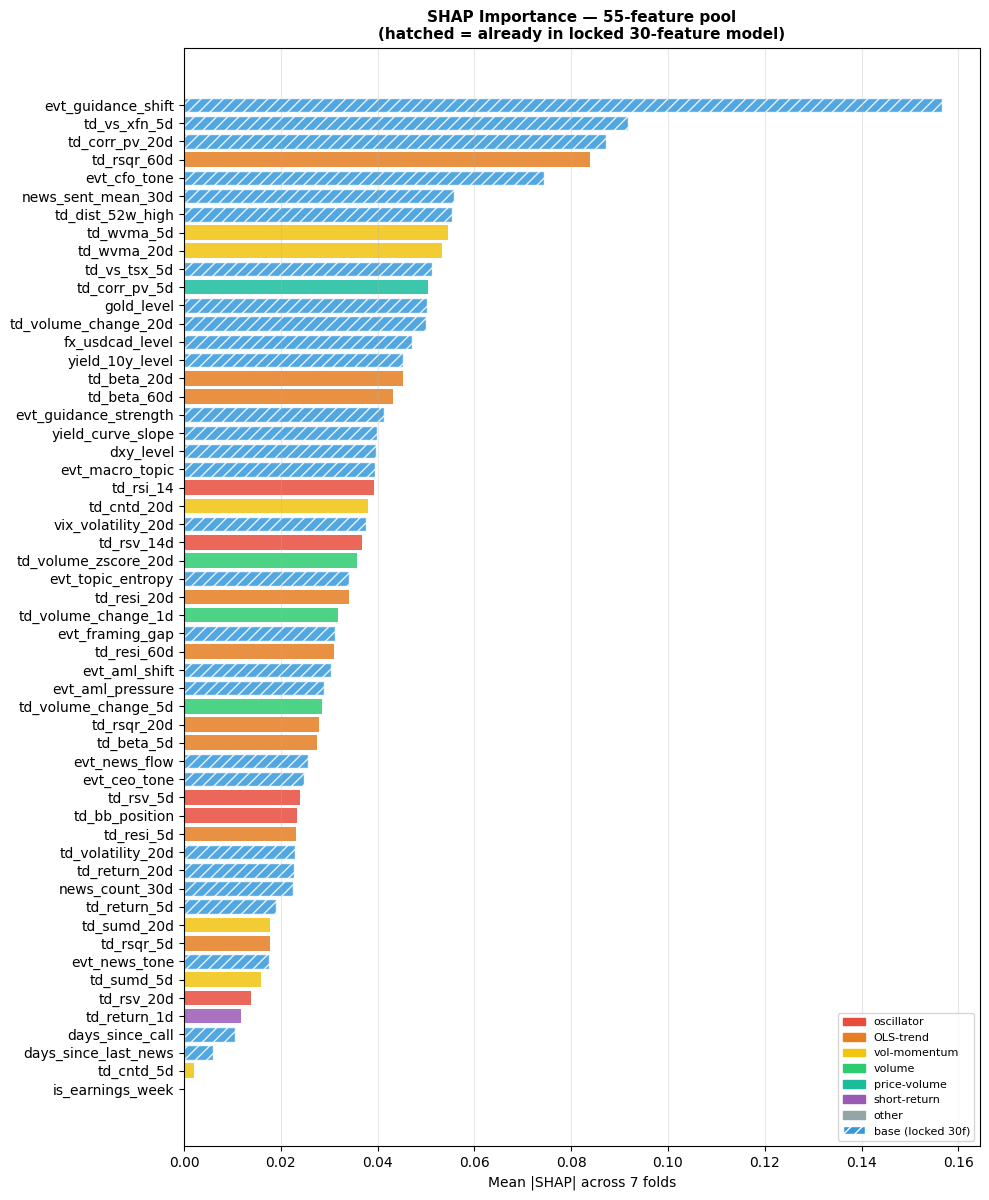

In [7]:
CAT_COLORS = {
    'oscillator':   '#e74c3c',
    'OLS-trend':    '#e67e22',
    'vol-momentum': '#f1c40f',
    'volume':       '#2ecc71',
    'price-volume': '#1abc9c',
    'short-return': '#9b59b6',
    'other':        '#95a5a6',
    'base':         '#3498db',
}

# Sort by global mean (ascending for horizontal bar)
sorted_feats = global_mean.index.tolist()[::-1]   # show bottom → top
colors = [CAT_COLORS.get(CATEGORY.get(f, 'base'), CAT_COLORS['base']) for f in sorted_feats]

fig, ax = plt.subplots(figsize=(10, max(8, len(sorted_feats) * 0.22)))
bars = ax.barh(sorted_feats, global_mean[sorted_feats].values, color=colors, alpha=0.85)

# Mark the base-feature bars differently
for i, feat in enumerate(sorted_feats):
    if feat in set(BASE_FEATURES):
        bars[i].set_hatch('///')
        bars[i].set_edgecolor('white')

ax.set_xlabel('Mean |SHAP| across 7 folds', fontsize=10)
ax.set_title(f'SHAP Importance — {len(POOL)}-feature pool\n(hatched = already in locked 30-feature model)',
             fontsize=11, fontweight='bold')
ax.axvline(0, color='#ddd', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items() if k != 'base']
patches.append(mpatches.Patch(facecolor=CAT_COLORS['base'], hatch='///', edgecolor='white', label='base (locked 30f)'))
ax.legend(handles=patches, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

## 7. Heatmap — TA Candidates Across Folds

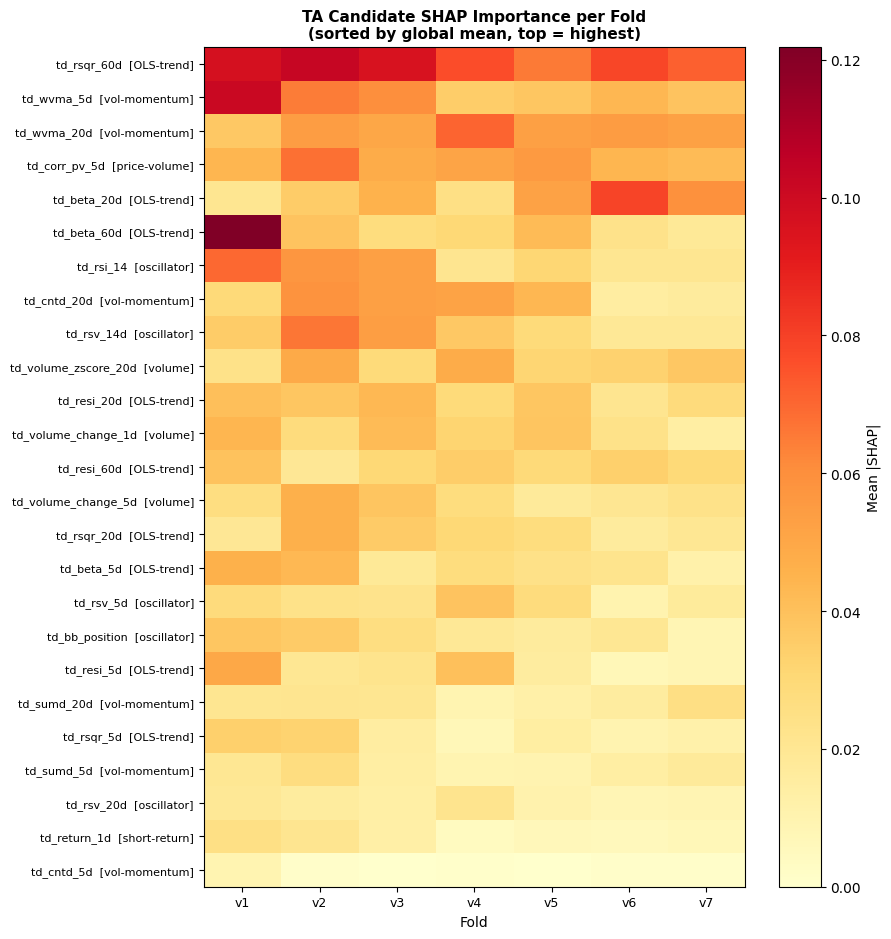

In [8]:
# Show only TA candidates (cleaner heatmap)
ta_sorted = [f for f in global_mean.index if f in set(TA_CANDIDATES)]
heat      = shap_df[ta_sorted].T   # (TA features × folds)

fig, ax = plt.subplots(figsize=(9, max(6, len(ta_sorted) * 0.38)))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=9)
ax.set_yticks(range(len(ta_sorted)))
ax.set_yticklabels([f'{f}  [{CATEGORY.get(f,"")}]' for f in ta_sorted], fontsize=8)
ax.set_xlabel('Fold', fontsize=10)
ax.set_title('TA Candidate SHAP Importance per Fold\n(sorted by global mean, top = highest)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout()
plt.show()

## 8. Key Findings

In [9]:
# Summarise which TA features look worth investigating
print('=== SHAP Selection Summary for TA Candidates ===\n')

TIERS = [
    ('Strong  (top-20 in 5+/7 folds)', lambda r, f20, f30: f20 >= 5),
    ('Moderate (top-20 in 3-4/7 folds)', lambda r, f20, f30: 3 <= f20 < 5),
    ('Weak    (top-30 in <3/7 folds)',  lambda r, f20, f30: f20 < 3 and f30 >= 1),
    ('Minimal (rarely in top-30)',      lambda r, f20, f30: f30 < 1),
]

for tier_name, condition in TIERS:
    tier_feats = [(rank, feat, val)
                  for rank, feat, val in ta_ranks
                  if condition(rank, freq[20].get(feat, 0), freq[30].get(feat, 0))]
    if not tier_feats:
        continue
    print(f'{tier_name}:')
    for rank, feat, val in tier_feats:
        f10 = freq[10].get(feat, 0)
        f20 = freq[20].get(feat, 0)
        f30 = freq[30].get(feat, 0)
        cat = CATEGORY.get(feat, '')
        print(f'  #{rank:<3} {feat:<30} [{cat:<13}]  SHAP={val:.4f}  '
              f'top10:{f10}/7  top20:{f20}/7  top30:{f30}/7')
    print()

=== SHAP Selection Summary for TA Candidates ===

Strong  (top-20 in 5+/7 folds):
  #4   td_rsqr_60d                    [OLS-trend    ]  SHAP=0.0839  top10:7/7  top20:7/7  top30:7/7
  #8   td_wvma_5d                     [vol-momentum ]  SHAP=0.0545  top10:3/7  top20:5/7  top30:7/7
  #9   td_wvma_20d                    [vol-momentum ]  SHAP=0.0532  top10:3/7  top20:6/7  top30:7/7
  #11  td_corr_pv_5d                  [price-volume ]  SHAP=0.0504  top10:2/7  top20:6/7  top30:7/7

Moderate (top-20 in 3-4/7 folds):
  #16  td_beta_20d                    [OLS-trend    ]  SHAP=0.0452  top10:2/7  top20:4/7  top30:5/7
  #22  td_rsi_14                      [oscillator   ]  SHAP=0.0392  top10:1/7  top20:3/7  top30:4/7
  #23  td_cntd_20d                    [vol-momentum ]  SHAP=0.0381  top10:1/7  top20:4/7  top30:4/7
  #26  td_volume_zscore_20d           [volume       ]  SHAP=0.0358  top10:0/7  top20:3/7  top30:5/7

Weak    (top-30 in <3/7 folds):
  #17  td_beta_60d                    [OLS-trend  